# Simulated Annealing for Adjacency Matrix Ordering

The goal of this notebook is to use **simulated annealing (SA)** to reorder the rows and columns of a connectivity adjacency matrix so that its community (module) structure becomes visually apparent as a block-diagonal pattern.

Given:
- A set of neurons with **community/module labels** (e.g. from RenEEL)
- A **connectivity edge list** (pre-neuron, post-neuron, synaptic weight)

We:
1. Build the adjacency matrix
2. Sort rows/columns by module label to create an initial block structure
3. Run **within-module simulated annealing** to push connection density toward the diagonal, without letting neurons cross module boundaries
4. Visualize the result with strict module boundaries and flexible display options

The step-by-step walkthrough in this notebook is intended to be readable and checkable. The final section calls `simulated_annealing.py`, which packages the same pipeline into a script that can be run directly on any data in the same format.

## What the notebook does and why

### The scientific question

We have a set of neurons that have been grouped into modules by RenEEL — a community detection algorithm. The question we are trying to answer visually is: **do neurons in the same module preferentially connect to each other?** If the modularity partition is meaningful, we would expect to see dense connectivity within modules and sparser connectivity between them. The adjacency matrix is how we test this visually.

---

### Step 1: Building the adjacency matrix

We take the two input dataframes — one with neuron IDs and their module labels, and one with directed synaptic connections and weights — and convert them into an $n \times n$ matrix where $n$ is the number of neurons. Each cell $[i, j]$ holds the synaptic weight from neuron $i$ to neuron $j$. The matrix is very sparse — most neurons do not connect to most other neurons — so the vast majority of entries are zero.

---

### Step 2: Sorting by module

If we plot the matrix in arbitrary neuron order it looks like random noise with no structure. The first step is to sort rows and columns so that all neurons from Module 1 appear first, then Module 2, and so on. This immediately reveals rough block structure along the diagonal — each block corresponds to within-module connectivity. However the blocks look noisy at this stage because within each module, neurons are still in arbitrary order.

---

### Step 3: Simulated Annealing

This is the core contribution of the notebook. Within each module block, we want to find a neuron ordering that pushes the densest connections as close to the diagonal as possible, making each block look tight and structured.

We define a cost function:

$$\text{cost} = \sum_{i,j} |i - j| \times \text{weight}[i,j]$$

This penalises connections that are far from the diagonal. A lower cost means connections are more concentrated near the diagonal — which is what we want.

We run simulated annealing to find a good ordering by:

1. Proposing a random swap of two neurons **within the same module**
2. If the swap reduces cost → always accept it
3. If the swap increases cost → accept it anyway with a probability that decreases over time (controlled by a "temperature" $T$)
4. Gradually cooling $T$ from high (explores freely) to near zero (only accepts improvements)

The key design decision is that **swaps are only ever proposed within a module** — a neuron can never cross a module boundary. This is what ensures the module colour bars stay clean with no bleed between blocks.

The parameters scale automatically with $n$:

- More neurons → more possible pairs to explore → more iterations needed
- The initial temperature is estimated from the data itself so that roughly 80% of cost-increasing moves are accepted at the start, regardless of the scale of the data

---

### Step 4: Visualisation

We produce two plots:

**Heatmap** — each cell is coloured by synaptic weight. We use a log scale visually (so weak connections are still visible) but the colorbar shows actual synapse counts so values can be read directly without calculating backwards. The colormap goes black → red → orange → yellow so even sparse connections show up as visible dark colours rather than near-white.

**Dot plot** — each connection above the 75th percentile is shown as a dot, with dot size proportional to actual synaptic weight. This makes it easy to see where the strongest individual connections are within and between modules.

Both plots have module colour bars on the top and left axes, and hard black boundary lines at exact module edges.

---

### Observations

- The block-diagonal structure confirms that neurons in the same module do preferentially connect to each other — within-module connectivity is denser than between-module connectivity
- The SA reordering makes this structure considerably cleaner compared to simply sorting by module label
- Some modules show very tight dense blocks (strong internal connectivity) while others are more diffuse — this reflects real differences in how tightly coupled those communities are
- The off-diagonal blocks are not entirely empty, which is expected — there is inter-module connectivity, but it is sparser than within-module connectivity

---

### How the code is structured

The notebook walks through everything step by step with sanity checks at each stage — intended to be readable and verifiable. The `.py` file packages the exact same logic into a script that can be handed to anyone and run on any dataset in the same format, without going through the pedagogical version.

In [1]:
# Imports
import numpy as np
import pandas as pd

In [2]:
# load packages for visualization
import matplotlib
import matplotlib.patheffects as path_effects
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator,FormatStrFormatter,MaxNLocator
%matplotlib inline

In [3]:
!pip install neuprint-python

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.7/109.7 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 7.0 MB/s eta 0:00:00
  Created wheel for asciitree: filename=asciitree-0.3.3-py3-none-any.whl size=5031 sha256=1c0ff98c30d7ca3c714354b3c4137ab0b0ac6f8dd6bdb44a488c2ec14f7570f1
  Stored in directory: /root/.cache/pip/wheels/a5/d7/98/f56ae733748cd0fa577172bda0e73e0b1f1793c98e09b9e458
Successfully built asciitree


In [4]:
import os
from google.colab import userdata
# load packages for neuprint
from neuprint import Client
auth_token = userdata.get('NEUPRINT_TOKEN')
c = Client('neuprint.janelia.org', dataset='hemibrain:v1.2.1', token=auth_token)
c.fetch_version()

'1.7.10'

# The data
We will read in the modularity data which will have been saved from running RenEEL elsewhere. Alternatively, we could read in any other kind of community labels. All that matters is that we are reading in a dataframe with 2 columns. The first column will have node IDs. The second column will have community labels. The community labels will be numbers in the case of module labels. In future cases, they could be strings -- for example, ROI labels that form our community structure.

In [5]:
# load module assignments directly from GitHub
import io, requests

MOD_URL = (
    'https://raw.githubusercontent.com/Gutierrez-lab/'
    'spatial-synapses-community-clustering/main/data/mod_results/0-0_98765.txt'
)
response = requests.get(MOD_URL)
response.raise_for_status()

mod = pd.read_csv(io.StringIO(response.text), header=None, sep=' ')
mod.columns = ['id', 'module']
mod

,id,module
0,1003215282,1
1,1005952640,2
2,1006928515,3
3,1007260806,3
4,1008024276,4
...,...,...
1827,987117151,2
1828,987273073,6
1829,988567837,5
1830,988909130,5


I'm going to get the connectivity data directly from Neuprint. It could also be read from a saved csv or some other source. What matters here is that this will always be a dataframe with 3 columns: pre ids, post ids, and weights.

The connectivity matrix below has directed connections. It would be ideal if the directedness could be maintained, but it is possible that the simulated annealing does not allow that.

In [6]:
from neuprint import fetch_simple_connections

# connections among inputs to oviIN
subconn_conns = fetch_simple_connections(mod['id'], mod['id'], min_weight=3)

# get rid of all the extra columns
subconn_conns = subconn_conns[['bodyId_pre', 'bodyId_post', 'weight']]
subconn_conns

,bodyId_pre,bodyId_post,weight
0,667266529,5901213440,618
1,422751191,5901213440,549
2,611629428,5901213440,505
3,976934253,326253554,492
4,299289811,487925063,485
...,...,...,...
73286,7112622044,1666561406,3
73287,7112622044,1787636059,3
73288,7112622044,5813027592,3
73289,7112622044,5813061024,3


# Visualizing the connectivity block matrix
Taking the dataframe of community labels and the dataframe of connectivity, plot a connectivity matrix that reveals the block structure of the communities. This requires that the rows and columns are ordered by the community labels. To further improve the visualization, use simulated annealing to further reorder rows and columns to push the connection density towards the diagonal.

Here, I'd like to see the process broken down in steps in a pedagogical way. Later, a function will be made from these steps in a separate script. In this section of the notebook, you can do small sanity checks and validate results at each step, even if those checks won't go into the separate function later.

## Step 1: Build the adjacency matrix

Convert the edge list into a dense `n × n` matrix `A` where `A[i,j]` is the synaptic weight from neuron `i` to neuron `j`. We use the node IDs from `mod` to define which neurons are included and in what order.

In [7]:
# Index neurons: assign each node ID a row/column index
node_ids = mod['id'].values                      # original (unordered) IDs
id_to_idx = {nid: i for i, nid in enumerate(node_ids)}
n = len(node_ids)

# Build the matrix
A = np.zeros((n, n), dtype=float)
for _, row in subconn_conns.iterrows():
    pre, post, w = row['bodyId_pre'], row['bodyId_post'], row['weight']
    if pre in id_to_idx and post in id_to_idx:
        A[id_to_idx[pre], id_to_idx[post]] += w

print(f"Matrix shape:     {A.shape}")
print(f"Non-zero entries: {np.count_nonzero(A):,}")
print(f"Matrix density:   {np.count_nonzero(A) / A.size:.4%}")

Matrix shape:     (1832, 1832)
Non-zero entries: 73,291
Matrix density:   2.1837%


**Sanity check:** total weight in the matrix should equal total weight in `subconn_conns` (for edges where both endpoints are in `mod`).

In [8]:
valid = set(mod['id'].values)
expected_weight = subconn_conns[
    subconn_conns['bodyId_pre'].isin(valid) & subconn_conns['bodyId_post'].isin(valid)
]['weight'].sum()

assert np.isclose(A.sum(), expected_weight),     f"Weight mismatch: matrix={A.sum():.0f}, expected={expected_weight:.0f}"
print(f"PASSED: total weight {A.sum():.0f} matches edge list.")

PASSED: total weight 801023 matches edge list.


## Step 2: Sort rows and columns by module label

Reorder rows and columns so neurons from the same module appear contiguously. This creates the initial block-diagonal structure before SA. We also compute `module_boundaries` — the indices where one module block ends and the next begins — which will be used to constrain SA swaps and draw boundary lines on the plot.

In [9]:
# Sort mod dataframe by module label
mod_sorted     = mod.sort_values('module').reset_index(drop=True)
ordered_ids    = mod_sorted['id'].values
module_labels  = mod_sorted['module'].values

# Compute block boundary indices: where does each module block start/end?
breaks             = np.where(np.diff(module_labels) != 0)[0] + 1
module_boundaries  = np.concatenate([[0], breaks, [n]])   # includes 0 and n

print("Module blocks:")
for k in range(len(module_boundaries) - 1):
    s, e   = module_boundaries[k], module_boundaries[k+1]
    mod_id = module_labels[s]
    print(f"  Module {mod_id}: {e-s:4d} neurons  (rows {s}–{e-1})")

# Reorder the adjacency matrix rows AND columns to match sorted order
perm    = np.array([id_to_idx[nid] for nid in ordered_ids])
A_sorted = A[np.ix_(perm, perm)]

Module blocks:
  Module 1:  309 neurons  (rows 0–308)
  Module 2:  199 neurons  (rows 309–507)
  Module 3:  319 neurons  (rows 508–826)
  Module 4:  347 neurons  (rows 827–1173)
  Module 5:  217 neurons  (rows 1174–1390)
  Module 6:  210 neurons  (rows 1391–1600)
  Module 7:  231 neurons  (rows 1601–1831)


**Sanity check:** total weight should be unchanged after reordering, and all module block sizes should sum to `n`.

In [10]:
assert np.isclose(A_sorted.sum(), A.sum()), "FAILED: weight changed after reordering"
assert module_boundaries[-1] == n,          "FAILED: boundary indices don't sum to n"
print(f"PASSED: {n} neurons, weight conserved, {len(module_boundaries)-1} module blocks.")

PASSED: 1832 neurons, weight conserved, 7 module blocks.


## Step 3: Define the cost function

Simulated annealing minimises a **cost** that measures how far connections are from the diagonal:

$$\text{cost} = \sum_{i,j} |i - j| \cdot A[i,j]$$

A lower cost means connections sit closer to the diagonal, i.e. the block structure is more compact. We also define an efficient **incremental** version that only recomputes the cost change for a proposed swap — this makes SA fast enough to run on ~1000–5000 nodes.

In [11]:
def compute_cost(A):
    """Total off-diagonal cost: sum of |i-j| * A[i,j]."""
    n   = A.shape[0]
    idx = np.arange(n)
    row_idx, col_idx = np.meshgrid(idx, idx, indexing='ij')
    dist = np.abs(row_idx - col_idx).astype(float)
    return float(np.sum(dist * A))

def delta_cost(A, i, j):
    """
    Incremental cost change from swapping positions i and j.
    Only rows/cols i and j are affected, so this is O(n) not O(n^2).
    """
    n   = A.shape[0]
    idx = np.arange(n)
    before = (
        np.sum(np.abs(idx - i) * A[i, :]) + np.sum(np.abs(idx - i) * A[:, i]) +
        np.sum(np.abs(idx - j) * A[j, :]) + np.sum(np.abs(idx - j) * A[:, j])
    )
    before -= np.abs(i - j) * (A[i, j] + A[j, i])   # avoid double-counting (i,j) cross terms

    after = (
        np.sum(np.abs(idx - j) * A[i, :]) + np.sum(np.abs(idx - j) * A[:, i]) +
        np.sum(np.abs(idx - i) * A[j, :]) + np.sum(np.abs(idx - i) * A[:, j])
    )
    after -= np.abs(i - j) * (A[i, j] + A[j, i])

    return after - before

cost_sorted = compute_cost(A_sorted)
print(f"Cost after module sorting (before SA): {cost_sorted:,.0f}")

Cost after module sorting (before SA): 274,624,448


**Sanity check:** sorting by module should give lower cost than a random ordering.

In [12]:
rng         = np.random.default_rng(0)
rand_perm   = rng.permutation(n)
cost_random = compute_cost(A_sorted[np.ix_(rand_perm, rand_perm)])

print(f"Cost (random ordering):  {cost_random:,.0f}")
print(f"Cost (module-sorted):    {cost_sorted:,.0f}")
assert cost_sorted <= cost_random, "FAILED: sorted order should cost less than random"
print("PASSED: module sorting improves over random ordering.")

Cost (random ordering):  479,198,347
Cost (module-sorted):    274,624,448
PASSED: module sorting improves over random ordering.


## Step 4: Within-module simulated annealing

We run SA **within each module block independently** — swaps are only proposed between neurons in the same module. This is the key constraint that prevents neurons from crossing module boundaries (which causes the colour bleed seen without this restriction).

**SA parameters scale automatically with `n`** so the same code works for matrices from ~50 to ~5000 nodes:

| Parameter | Formula | Intuition |
|-----------|---------|----------|
| `n_iter` | `max(50 000, n² / 5)` | More nodes → more pairs to explore |
| `T_init` | Estimated from random swaps | Accept ~80% of cost-worsening moves at start |
| `T_final` | `1e-3` | Near-zero: only clearly good moves accepted |
| Cooling | Geometric: `T_init → T_final` over `n_iter` steps | Smooth exponential schedule |

In [13]:
import math, random, time

def estimate_T_init(A, module_boundaries, n_samples=500, accept_prob=0.80):
    """
    Set T_init so that ~accept_prob of cost-increasing swaps are accepted
    at the start. Uses: T = -mean(delta_E) / ln(accept_prob).
    """
    eligible = [k for k in range(len(module_boundaries) - 1)
                if module_boundaries[k+1] - module_boundaries[k] >= 2]
    deltas = []
    for _ in range(n_samples):
        k      = random.choice(eligible)
        s, e   = module_boundaries[k], module_boundaries[k+1]
        i, j   = random.sample(range(s, e), 2)
        d      = delta_cost(A, i, j)
        if d > 0:
            deltas.append(d)
    if not deltas:
        return 1.0
    return -float(np.mean(deltas)) / math.log(accept_prob)


def simulated_annealing(A, module_boundaries, n_iter=None, T_init=None,
                        T_final=1e-3, seed=42, verbose=True):
    """
    Reorder neurons within each module to minimise off-diagonal cost.

    Parameters
    ----------
    A                 : adjacency matrix, already sorted by module
    module_boundaries : block-boundary indices from Step 2
    n_iter            : SA iterations (None = auto: max(50_000, n^2/5))
    T_init            : initial temperature (None = auto-estimated)
    T_final           : final temperature
    seed              : random seed for reproducibility
    verbose           : print progress

    Returns
    -------
    A_best       : best adjacency matrix found
    order_best   : permutation array (position in input → position in output)
    cost_history : list of (step, cost) tuples for convergence checking
    """
    random.seed(seed)
    np.random.seed(seed)

    n = A.shape[0]
    if n_iter is None:
        n_iter = max(50_000, n * n // 5)
    if T_init is None:
        T_init = estimate_T_init(A, module_boundaries)

    cooling = (T_final / T_init) ** (1.0 / n_iter)

    if verbose:
        print(f"n={n},  n_iter={n_iter:,},  T_init={T_init:.4f},  "
              f"T_final={T_final:.2e},  cooling={cooling:.8f}")

    A_curr    = A.copy()
    order     = np.arange(n)
    T         = T_init
    cost      = compute_cost(A_curr)
    best_cost = cost
    best_A    = A_curr.copy()
    best_ord  = order.copy()

    eligible    = [k for k in range(len(module_boundaries) - 1)
                   if module_boundaries[k+1] - module_boundaries[k] >= 2]
    log_step    = max(1, n_iter // 10)
    cost_history = [(0, cost)]

    for step in range(1, n_iter + 1):
        k    = random.choice(eligible)
        s, e = module_boundaries[k], module_boundaries[k+1]
        i, j = random.sample(range(s, e), 2)

        d = delta_cost(A_curr, i, j)
        if d < 0 or random.random() < math.exp(-d / T):
            A_curr[[i, j], :] = A_curr[[j, i], :]
            A_curr[:, [i, j]] = A_curr[:, [j, i]]
            order[[i, j]]     = order[[j, i]]
            cost += d
            if cost < best_cost:
                best_cost = cost
                best_A    = A_curr.copy()
                best_ord  = order.copy()

        T *= cooling

        if verbose and step % log_step == 0:
            cost_history.append((step, cost))
            print(f"  {100*step/n_iter:5.1f}%  T={T:.4f}  cost={cost:,.0f}  best={best_cost:,.0f}")

    cost_history.append((n_iter, best_cost))
    return best_A, best_ord, cost_history


print("Running SA...")
t0 = time.time()
A_opt, order_opt, cost_history = simulated_annealing(A_sorted, module_boundaries)
print(f"Done in {time.time()-t0:.1f}s")

Running SA...
n=1832,  n_iter=671,244,  T_init=132537.2807,  T_final=1.00e-03,  cooling=0.99997214
   10.0%  T=20422.5087  cost=224,934,172  best=224,915,060
   20.0%  T=3146.8796  cost=209,466,843  best=209,451,697
   30.0%  T=484.8989  cost=205,824,153  best=205,824,153
   40.0%  T=74.7175  cost=205,012,202  best=205,012,202
   50.0%  T=11.5131  cost=204,755,628  best=204,755,628
   60.0%  T=1.7740  cost=204,616,632  best=204,616,632
   70.0%  T=0.2734  cost=204,527,938  best=204,527,938
   80.0%  T=0.0421  cost=204,469,879  best=204,469,879
   90.0%  T=0.0065  cost=204,425,766  best=204,425,766
  100.0%  T=0.0010  cost=204,375,745  best=204,375,745
Done in 152.6s


**Sanity check 1:** SA should reduce cost compared to the initial module-sorted ordering.

In [14]:
cost_opt = compute_cost(A_opt)
print(f"Cost after module sorting: {cost_sorted:,.0f}")
print(f"Cost after SA:             {cost_opt:,.0f}")
assert cost_opt <= cost_sorted, "FAILED: SA did not improve cost"
print(f"PASSED: {100*(cost_sorted-cost_opt)/cost_sorted:.1f}% improvement.")

Cost after module sorting: 274,624,448
Cost after SA:             219,015,015
PASSED: 20.2% improvement.


**Sanity check 2:** No neuron should have crossed a module boundary during SA.

In [15]:
for k in range(len(module_boundaries) - 1):
    s, e        = module_boundaries[k], module_boundaries[k+1]
    expected    = module_labels[s]
    actual_mods = module_labels[order_opt[s:e]]
    assert np.all(actual_mods == expected),         f"FAILED: neurons crossed boundary in module {expected}"
print("PASSED: all neurons stayed within their module blocks.")

PASSED: all neurons stayed within their module blocks.


**Convergence plot:** a smooth early drop followed by flattening indicates healthy cooling.

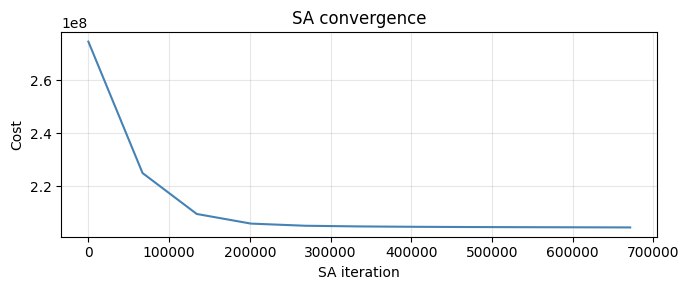

In [16]:
steps, costs = zip(*cost_history)
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(steps, costs, lw=1.5, color='steelblue')
ax.set_xlabel('SA iteration')
ax.set_ylabel('Cost')
ax.set_title('SA convergence')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 5: Visualize the reordered matrix

We plot the SA-optimized matrix with:
- **Module colour bars** on the top and left axes
- **Strict boundary lines** at exact module edges (no bleed)
- Choice of **log scale** or **raw weight** for the colour map
- Optional **dot mode** where each edge is a scatter point sized by weight
- Optional **polar (cyclic) colormap** for module colours

In [21]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib.patches as mpatches

N_MODULES  = len(module_boundaries) - 1
MOD_COLORS = list(plt.cm.tab10.colors[:N_MODULES])


def plot_adjacency_matrix(A, module_labels, module_boundaries,
                           dot_mode=False, max_dot_size=80,
                           mod_colors=None, title='Adjacency matrix (SA-ordered)',
                           save_path=None, figsize=(10, 9)):
    n         = A.shape[0]
    n_modules = len(module_boundaries) - 1
    if mod_colors is None:
        mod_colors = list(plt.cm.tab10.colors[:n_modules])

    mod_cmap  = ListedColormap(mod_colors[:n_modules])
    color_bar = np.array([k for k in range(n_modules)
                           for _ in range(module_boundaries[k+1] - module_boundaries[k])],
                          dtype=float)

    fig = plt.figure(figsize=figsize)
    gs  = fig.add_gridspec(2, 3,
                            width_ratios=[0.025, 1, 0.06],
                            height_ratios=[0.025, 1],
                            hspace=0.02, wspace=0.08)
    ax_top  = fig.add_subplot(gs[0, 1])
    ax_left = fig.add_subplot(gs[1, 0])
    ax_main = fig.add_subplot(gs[1, 1])
    ax_cbar = fig.add_subplot(gs[1, 2])

    # Module colour bars
    ax_top.imshow(color_bar[np.newaxis, :], aspect='auto',
                  cmap=mod_cmap, vmin=0, vmax=n_modules, interpolation='none')
    ax_left.imshow(color_bar[:, np.newaxis], aspect='auto',
                   cmap=mod_cmap, vmin=0, vmax=n_modules, interpolation='none')
    ax_top.set_xlim(-0.5, n - 0.5)
    ax_left.set_ylim(n - 0.5, -0.5)
    for ax in [ax_top, ax_left]:
        ax.set_xticks([]); ax.set_yticks([])

    if dot_mode:
        # Y ticks and label on right so they don't overlap the left colour bar
        ax_main.yaxis.tick_right()
        ax_main.yaxis.set_tick_params(labelsize=9)
        ax_main.yaxis.set_label_position('right')
        rows, cols = np.where(A > 0)
        weights    = A[rows, cols]
        threshold  = np.percentile(weights, 75)
        mask       = weights >= threshold
        rows, cols, weights = rows[mask], cols[mask], weights[mask]
        w_min, w_max = weights.min(), weights.max()
        sizes = ((weights - w_min) / (w_max - w_min)) ** 2 * max_dot_size + 3
        ax_main.scatter(cols, rows, s=sizes, c='steelblue', alpha=0.6, linewidths=0)
        ax_main.set_facecolor('white')
        ax_main.set_xlim(-0.5, n - 0.5)
        ax_main.set_ylim(n - 0.5, -0.5)
        ax_cbar.set_visible(False)
        ax_main.set_ylabel('Postsynaptic neuron (ordered)', fontsize=11, labelpad=12)
    else:
        ax_main.set_yticks([])
        disp = np.log1p(A.copy())
        disp[disp == 0] = np.nan
        nonzero_vals = disp[~np.isnan(disp)]
        vmax = np.percentile(nonzero_vals, 90) if len(nonzero_vals) > 0 else None
        # Truncate colormap to skip near-white shades — weakest connections
        # start at a visible pink rather than barely distinguishable from white
        rdpu_truncated = LinearSegmentedColormap.from_list(
            'RdPu_truncated', plt.cm.RdPu(np.linspace(0.15, 1.0, 256))
        )
        im   = ax_main.imshow(disp, aspect='auto', cmap=rdpu_truncated,
                               interpolation='none', origin='upper',
                               vmin=0, vmax=vmax)
        cbar = fig.colorbar(im, cax=ax_cbar)
        tick_locs   = cbar.get_ticks()
        tick_labels = [f'{np.expm1(t):.0f}' for t in tick_locs]
        cbar.set_ticks(tick_locs)
        cbar.set_ticklabels(tick_labels)
        cbar.set_label('Synaptic weight', fontsize=10, labelpad=15)

    # Module boundaries
    bkw = dict(color='black', linewidth=1.5, linestyle='-')
    for b in module_boundaries[1:-1]:
        ax_main.axhline(b - 0.5, **bkw);  ax_main.axvline(b - 0.5, **bkw)
        ax_top.axvline(b - 0.5, **bkw);   ax_left.axhline(b - 0.5, **bkw)

    # Module legend
    mod_ids = [module_labels[module_boundaries[k]] for k in range(n_modules)]
    patches = [mpatches.Patch(color=mod_colors[k], label=f'Module {mod_ids[k]}')
               for k in range(n_modules)]
    ax_main.legend(handles=patches, loc='upper left', fontsize=8,
                   framealpha=0.85, title='Module', title_fontsize=9)

    ax_main.set_xlabel('Presynaptic neuron (ordered)', fontsize=11)
    ax_top.set_title(title, fontsize=12, pad=6)

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()
    plt.close()

### Plots - Heatmap and Dot plot

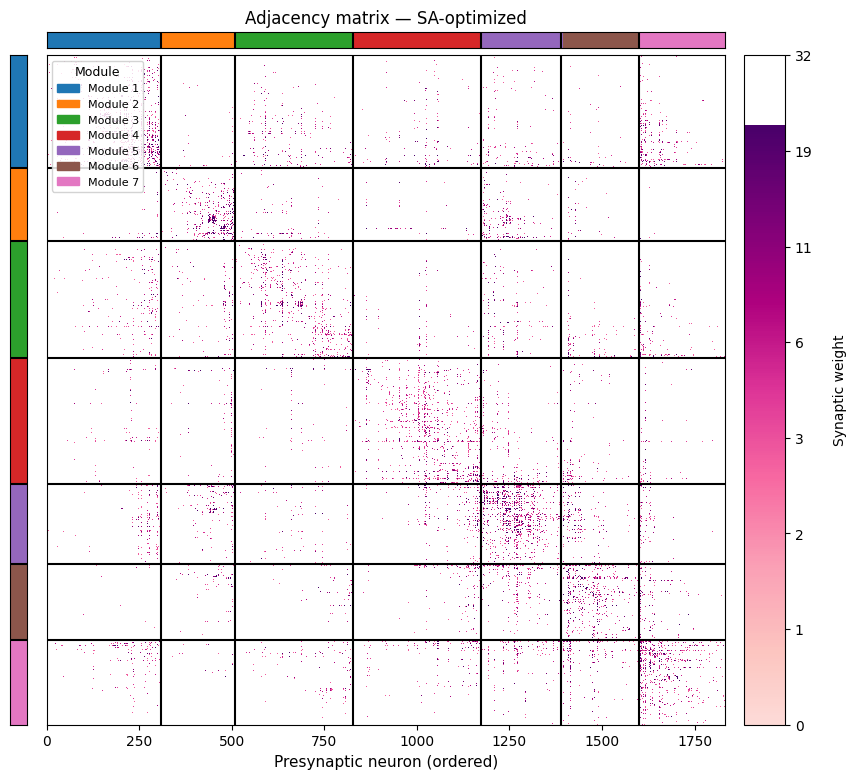

In [22]:
plot_adjacency_matrix(A_opt, module_labels, module_boundaries,
                      title='Adjacency matrix — SA-optimized')

Saved: adjacency_dots.png


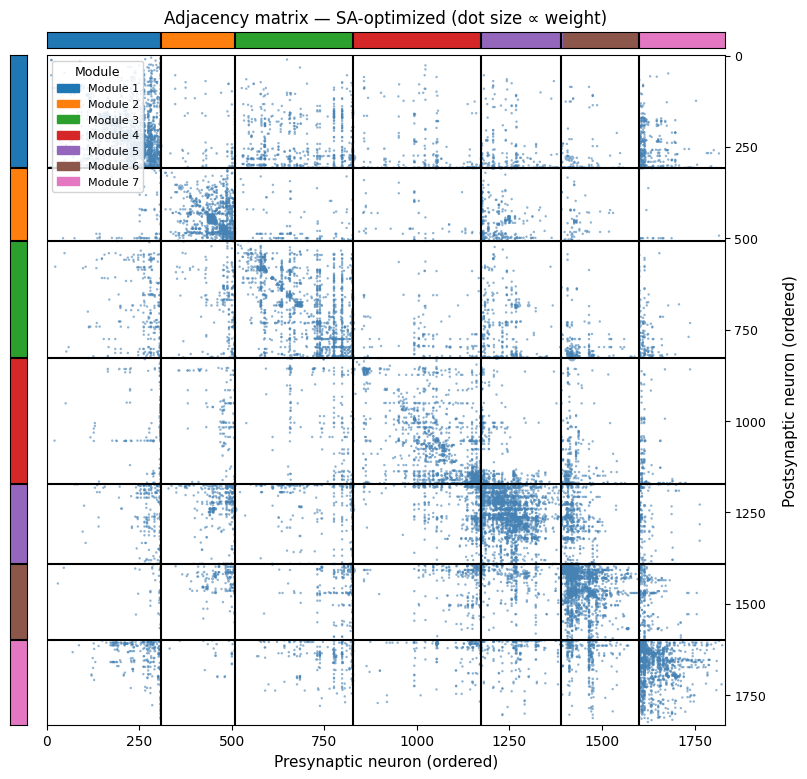

In [23]:
plot_adjacency_matrix(A_opt, module_labels, module_boundaries,
                      dot_mode=True,
                      title='Adjacency matrix — SA-optimized (dot size ∝ weight)',
                      save_path='adjacency_dots.png')

# Function(s) for doing the above
Below, create Python functions for doing what was done above. Alternatively, the functions could go into a separate .py script.
As a sanity check, show that the results match when you call the function using the inputs from this notebook.

In [24]:
def run_pipeline(mod_df, conn_df, min_weight=1,
                 max_dot_size=80, mod_colors=None, polar_cmap=False,
                 n_iter=None, T_init=None, T_final=1e-3, seed=42,
                 title='Adjacency matrix (SA-optimized)', save_path=None, verbose=True):
    """
    Full pipeline: two dataframes in, both plots out (heatmap + dot plot).

    Parameters
    ----------
    mod_df      : DataFrame with columns ['id', 'module']
    conn_df     : DataFrame with columns ['bodyId_pre', 'bodyId_post', 'weight']
    min_weight  : discard edges below this threshold
    max_dot_size: max dot size in dot plot
    mod_colors  : explicit colour list per module; overrides polar_cmap
    polar_cmap  : use HSV cyclic colourmap if True
    n_iter      : SA iterations (None = auto-scale with n)
    T_init      : initial temperature (None = auto-estimate)
    T_final     : final temperature
    seed        : random seed
    title       : base title for both plots
    save_path   : if given, saves heatmap as save_path and dot plot as save_path_dots.png
    verbose     : print SA progress

    Returns
    -------
    dict: A_optimized, module_labels, module_boundaries, cost_history
    """
    import time, matplotlib.cm as cm

    rename = {'bodyId_pre': 'pre', 'bodyId_post': 'post'}
    conn   = conn_df.rename(columns=rename)[['pre', 'post', 'weight']].copy()
    conn   = conn[conn['weight'] >= min_weight].reset_index(drop=True)

    node_ids  = mod_df['id'].values
    id_to_idx = {nid: i for i, nid in enumerate(node_ids)}
    N         = len(node_ids)
    A         = np.zeros((N, N), dtype=float)
    for _, row in conn.iterrows():
        pre, post, w = row['pre'], row['post'], row['weight']
        if pre in id_to_idx and post in id_to_idx:
            A[id_to_idx[pre], id_to_idx[post]] += w

    mod_s      = mod_df.sort_values('module').reset_index(drop=True)
    ord_ids    = mod_s['id'].values
    mod_labels = mod_s['module'].values
    breaks     = np.where(np.diff(mod_labels) != 0)[0] + 1
    mod_bounds = list(np.concatenate([[0], breaks, [N]]))

    perm     = np.array([id_to_idx[nid] for nid in ord_ids])
    A_sorted = A[np.ix_(perm, perm)]

    if verbose: print("Running simulated annealing...")
    t0 = time.time()
    A_opt, order_opt, cost_hist = simulated_annealing(
        A_sorted, mod_bounds, n_iter=n_iter, T_init=T_init,
        T_final=T_final, seed=seed, verbose=verbose)
    if verbose: print(f"Elapsed: {time.time()-t0:.1f}s")

    n_mods = len(mod_bounds) - 1
    if mod_colors is None:
        colors = ([cm.hsv(i/n_mods) for i in range(n_mods)]
                  if polar_cmap else list(plt.cm.tab10.colors[:n_mods]))
    else:
        colors = mod_colors

    # Plot 1: heatmap
    plot_adjacency_matrix(A_opt, mod_labels, mod_bounds,
                          dot_mode=False, mod_colors=colors,
                          title=title + ' (heatmap)',
                          save_path=save_path)

    # Plot 2: dot plot
    dot_save = save_path.replace('.png', '_dots.png') if save_path else None
    plot_adjacency_matrix(A_opt, mod_labels, mod_bounds,
                          dot_mode=True, max_dot_size=max_dot_size,
                          mod_colors=colors,
                          title=title + ' (dot size ∝ weight)',
                          save_path=dot_save)

    return dict(A_optimized=A_opt, module_labels=mod_labels,
                module_boundaries=mod_bounds, cost_history=cost_hist)

print("run_pipeline defined.")

run_pipeline defined.


Running simulated annealing...
n=1832,  n_iter=671,244,  T_init=132537.2807,  T_final=1.00e-03,  cooling=0.99997214
   10.0%  T=20422.5087  cost=224,934,172  best=224,915,060
   20.0%  T=3146.8796  cost=209,466,843  best=209,451,697
   30.0%  T=484.8989  cost=205,824,153  best=205,824,153
   40.0%  T=74.7175  cost=205,012,202  best=205,012,202
   50.0%  T=11.5131  cost=204,755,628  best=204,755,628
   60.0%  T=1.7740  cost=204,616,632  best=204,616,632
   70.0%  T=0.2734  cost=204,527,938  best=204,527,938
   80.0%  T=0.0421  cost=204,469,879  best=204,469,879
   90.0%  T=0.0065  cost=204,425,766  best=204,425,766
  100.0%  T=0.0010  cost=204,375,745  best=204,375,745
Elapsed: 152.2s


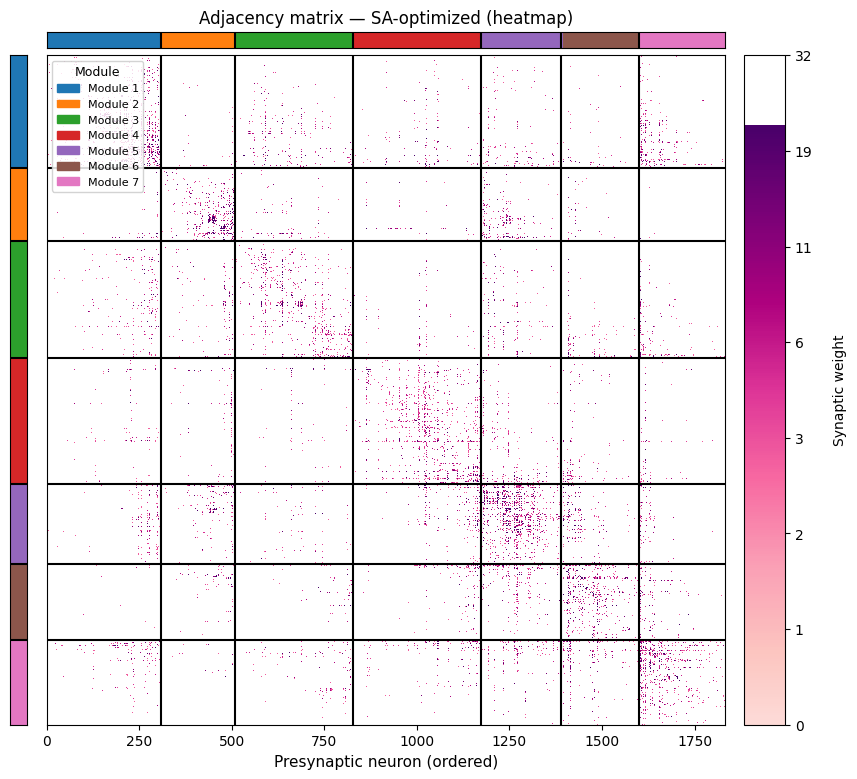

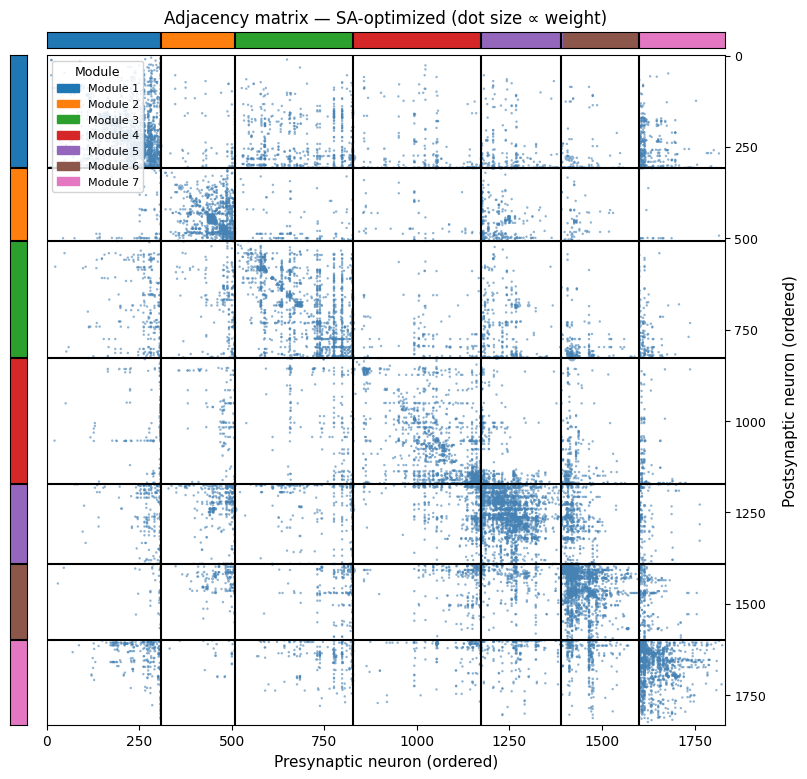

In [25]:
results = run_pipeline(
    mod_df     = mod,
    conn_df    = subconn_conns,
    min_weight = 3,
    seed       = 42,
    title      = 'Adjacency matrix — SA-optimized',
)

# Calling the standalone script

The full pipeline — build matrix, run SA, plot — is also packaged in `adjacency_matrix.py`.
This script takes the same two dataframes as input and runs without the step-by-step explanations or visualizations of intermediate steps. Use it when you just want the final result quickly, or when handing off a standard analysis to someone else.

**From the command line:**
```bash
python adjacency_matrix.py \
    --mod  data/mod_results/0-0_98765.txt \
    --conn data/connections.csv \
    --min-weight 3 \
    --log-scale \
    --save output_matrix
```

**From Python (e.g. in a notebook):** import and call `run_pipeline()` directly with the same dataframes used above.

Fetching module file from https://raw.githubusercontent.com/Gutierrez-lab/spatial-synapses-community-clustering/main/data/mod_results/0-0_98765.txt...
Loaded 1,832 neurons across 7 modules.
Connecting to Neuprint (hemibrain:v1.2.1)...
Fetched 73,291 connections from Neuprint.
Running simulated annealing...
n=1832,  n_iter=671,244,  T_init=132537.2807,  T_final=1.00e-03,  cooling=0.99997214
   10.0%  T=20422.5087  cost=224,934,172  best=224,915,060
   20.0%  T=3146.8796  cost=209,466,843  best=209,451,697
   30.0%  T=484.8989  cost=205,824,153  best=205,824,153
   40.0%  T=74.7175  cost=205,012,202  best=205,012,202
   50.0%  T=11.5131  cost=204,755,628  best=204,755,628
   60.0%  T=1.7740  cost=204,616,632  best=204,616,632
   70.0%  T=0.2734  cost=204,527,938  best=204,527,938
   80.0%  T=0.0421  cost=204,469,879  best=204,469,879
   90.0%  T=0.0065  cost=204,425,766  best=204,425,766
  100.0%  T=0.0010  cost=204,375,745  best=204,375,745
Elapsed: 150.2s
Saved: output_matrix.png
Figur

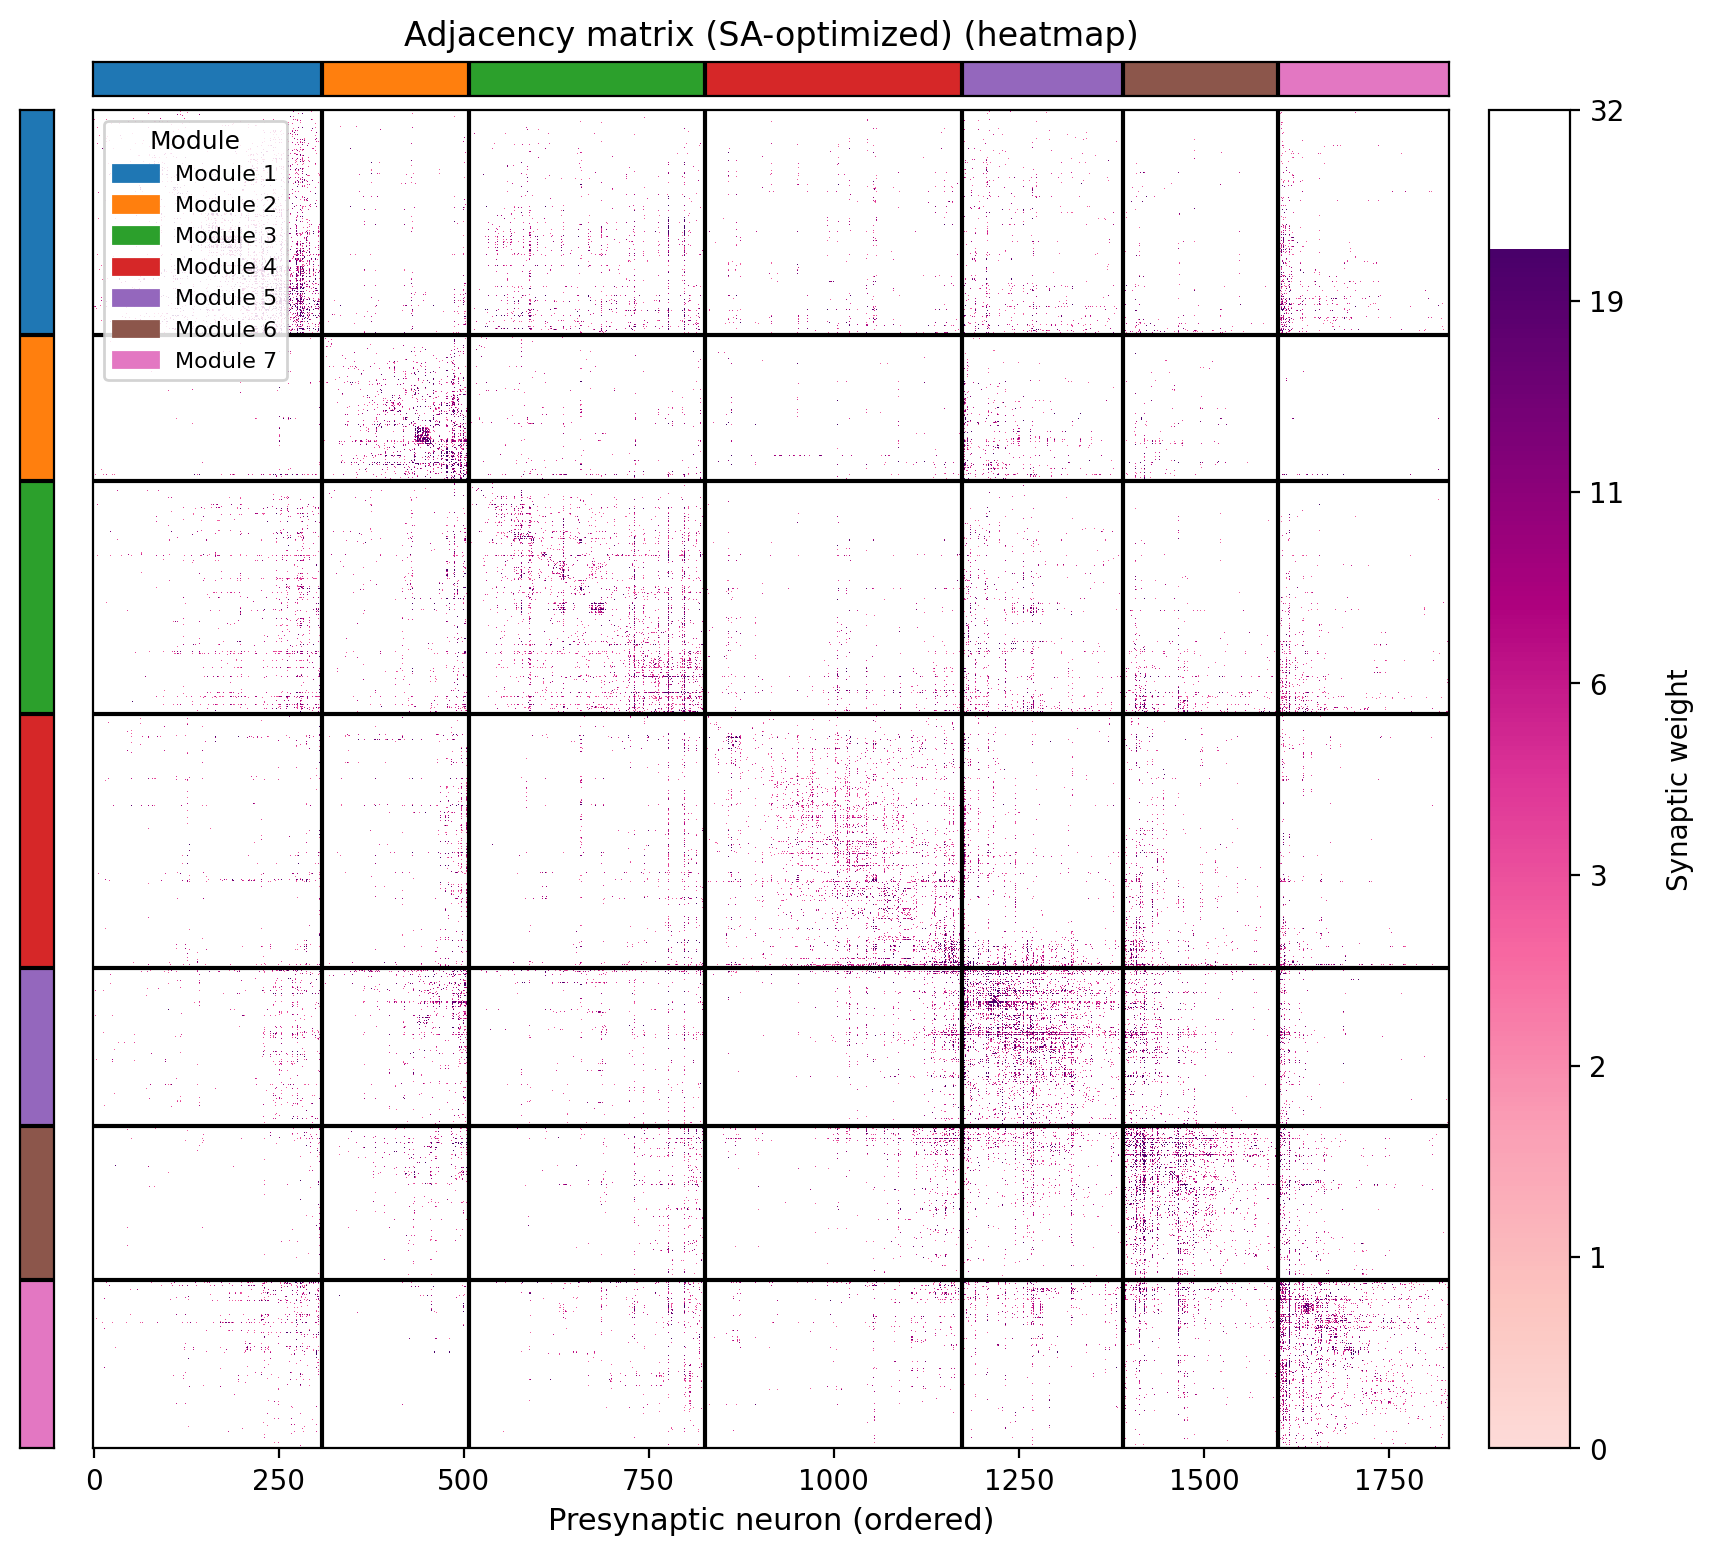

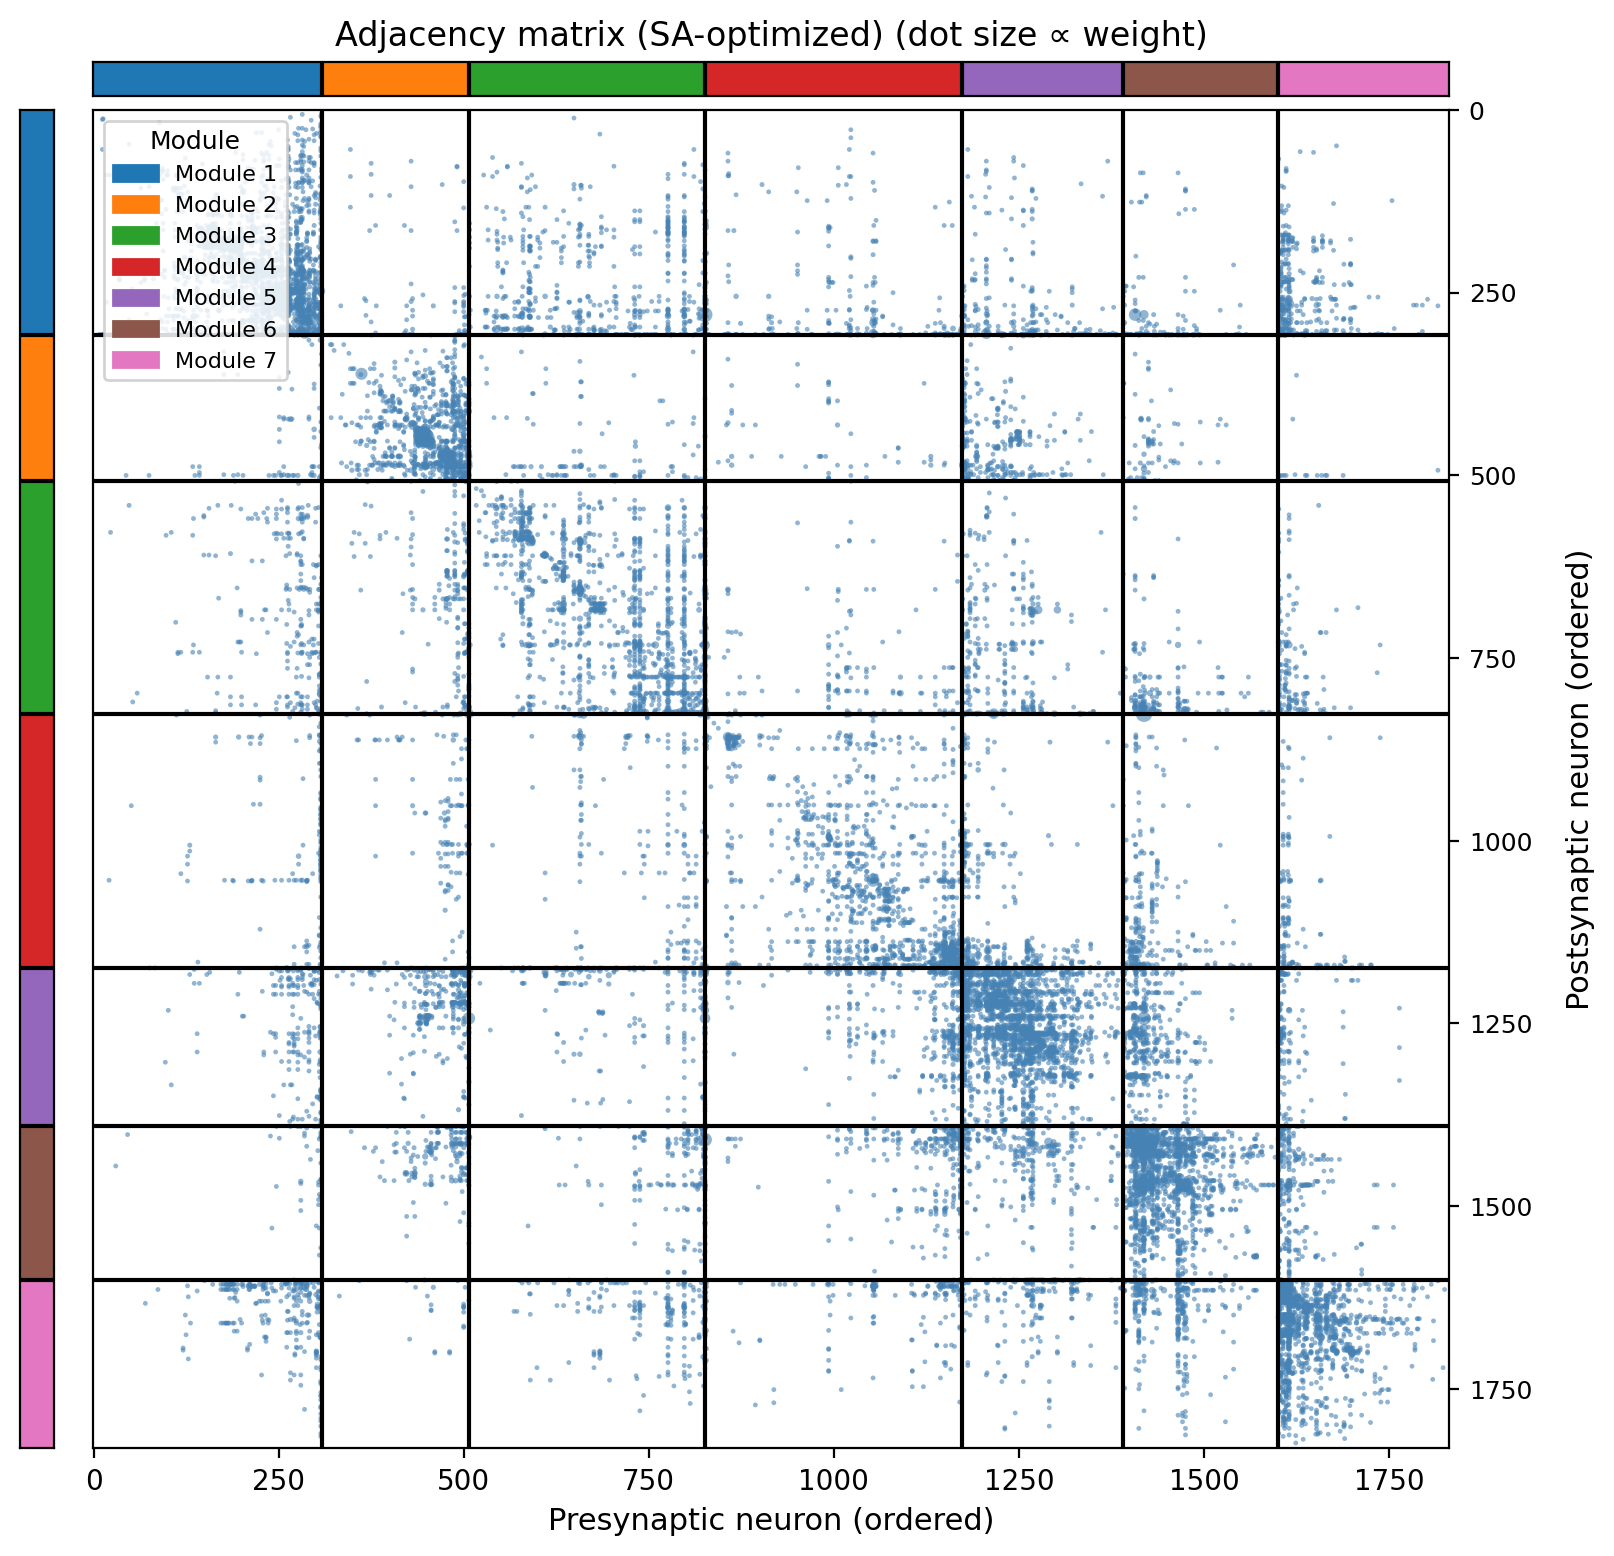

In [26]:
import os
from google.colab import userdata
from IPython.display import Image, display

os.environ['NEUPRINT_TOKEN'] = userdata.get('NEUPRINT_TOKEN')

!python simulated_annealing.py \
    --mod-url  https://raw.githubusercontent.com/Gutierrez-lab/spatial-synapses-community-clustering/main/data/mod_results/0-0_98765.txt \
    --neuprint \
    --min-weight 3 \
    --save output_matrix

# Display the saved plots inline
display(Image('output_matrix.png'))
display(Image('output_matrix_dots.png'))